## ``Modern Portfolio Theory - Markowitz Efficient Frontiner``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns
import plotly as py
import plotly.graph_objs as go

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)

In [2]:
# NASDAQ (NDX) - Top 20 Stock Asset Prices

nasdaq_tck = [
    'AAPL',  # Apple
    'MSFT',  # Microsoft
    'GOOGL', # Alphabet (Google)
    'AMZN',  # Amazon
    'NVDA',  # NVIDIA
    'META',  # FB (Meta)
    'TSLA',  # Tesla
    'PYPL',  # PayPal
    'ADBE',  # Adobe
    'CSCO',  # Cisco Systems
    'AMD',   # Advanced Micro Devices
    'INTC',  # Intel
    'NFLX',  # Netflix
    'ZM',    # Zoom Video Communications
    'MRNA',  # Moderna
    'AMAT',  # Applied Materials
    'QCOM',  # Qualcomm
    'ASML',  # ASML
    'AVGO',   # Broadcom
    'SMCI',  # Super Micro Computer
]

# ndx_data = {}
# for ticker in nasdaq_tck:
#     stock_data = yf.download(ticker, start = '2024-01-01', end = '2025-01-01')
#     ndx_data[ticker] = stock_data.Close

# ndx_df = pd.concat(ndx_data, axis = 1)
# ndx_df.to_csv('../data/data_EfficientFrontier/nasdaq_data.csv', index = True)
ndx_df = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/PortfolioOptimization/data/data_EfficientFrontier/nasdaq_data.csv', index_col = 0)
ndx_df = ndx_df.iloc[2:]
ndx_df = ndx_df.apply(pd.to_numeric, errors = 'coerce')
ndx_df.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,PYPL,ADBE,CSCO,AMD,INTC,NFLX,ZM,MRNA,AMAT,QCOM,ASML,AVGO,SMCI
2024-01-02,184.532089,367.380615,137.670929,149.929993,48.154346,344.972260,248.419998,61.459999,580.070007,48.586624,138.580002,47.168278,468.500000,69.150002,112.500000,152.821915,137.518112,711.210693,107.095505,28.545000
2024-01-03,183.150391,367.113159,138.418213,148.470001,47.555519,343.159180,238.449997,58.630001,571.789978,48.964691,135.320007,46.428196,470.260010,67.169998,108.580002,149.931198,134.938995,697.768555,104.451111,28.063999
2024-01-04,180.824356,364.478180,135.897369,144.570007,47.984398,345.799072,237.929993,58.450001,567.049988,48.547848,136.009995,46.250572,474.670013,66.900002,108.660004,147.812668,133.536621,694.713135,103.506828,28.879999
2024-01-05,180.098694,364.290009,135.239731,145.240005,49.083080,350.610687,237.490005,60.119999,564.599976,48.557541,138.580002,46.270309,474.059998,66.959999,111.120003,147.505768,134.085800,697.738892,103.533478,29.212999
2024-01-08,184.452545,371.164703,138.338501,149.100006,52.238186,357.295166,240.449997,61.740002,580.549988,48.916222,146.179993,47.809692,485.029999,68.389999,115.440002,150.040085,136.341324,715.099548,106.056496,32.028000


In [3]:
# Plot
def df_plot(df, title, ylabel):
    
    fig = plt.figure(figsize = (12, 4))
    ax = fig.gca()
    ax.set_facecolor('whitesmoke')
    for asset in df.columns.values:
        ax.plot(df.index, df[asset], label = asset, linewidth = 1)

    plt.grid(linestyle = '--')
    plt.title(title, fontsize = 12, fontweight = 'bold')

    plt.ylabel(ylabel, fontsize = 8)
    ax.tick_params(axis = 'y', labelsize = 8)

    plt.xlabel('Date', fontsize = 8)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval = 30))
    ax.tick_params(axis = 'x', labelsize = 8, rotation = 45)

    legend = plt.legend(prop = {'size': 8}, frameon = True, loc = 'upper left')
    legend.get_frame().set_linewidth(0.5)

    return

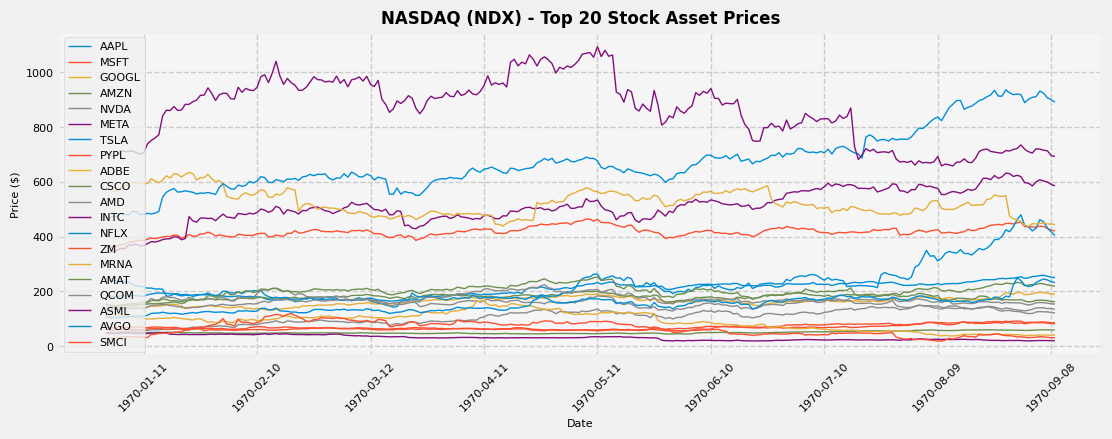

In [4]:
# Plot - Top 20 Stock Asset Prices
df_plot(df = ndx_df, title = 'NASDAQ (NDX) - Top 20 Stock Asset Prices', ylabel = 'Price ($)')

In [5]:
# Yield / Returns
def yield_return(df):
    yield_df = np.log(df) - np.log(df.shift(1))
    yield_df = yield_df.iloc[1:, :]
    return yield_df

ndx_yield_df = yield_return(ndx_df)
ndx_yield_df.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,PYPL,ADBE,CSCO,AMD,INTC,NFLX,ZM,MRNA,AMAT,QCOM,ASML,AVGO,SMCI
2024-01-03,-0.007516,-0.000728,0.005413,-0.009786,-0.012514,-0.005270,-0.040961,-0.047140,-0.014377,0.007751,-0.023805,-0.015815,0.003750,-0.029051,-0.035466,-0.019097,-0.018933,-0.019081,-0.025002,-0.016994
2024-01-04,-0.012781,-0.007203,-0.018380,-0.026619,0.008978,0.007663,-0.002183,-0.003075,-0.008324,-0.008550,0.005086,-0.003833,0.009334,-0.004028,0.000737,-0.014231,-0.010447,-0.004388,-0.009082,0.028662
2024-01-05,-0.004021,-0.000516,-0.004851,0.004624,0.022638,0.013819,-0.001851,0.028171,-0.004330,0.000200,0.018719,0.000427,-0.001286,0.000896,0.022387,-0.002078,0.004104,0.004346,0.000257,0.011465
2024-01-08,0.023887,0.018696,0.022655,0.026230,0.062299,0.018886,0.012387,0.026589,0.027858,0.007360,0.053391,0.032728,0.022877,0.021131,0.038140,0.017035,0.016682,0.024577,0.024077,0.091997
2024-01-09,-0.002266,0.002931,0.015083,0.015110,0.016833,-0.003435,-0.023097,-0.011239,0.009685,-0.010960,0.020851,-0.008290,-0.006080,-0.001170,-0.046636,-0.003503,0.006167,-0.006807,0.007083,0.070661


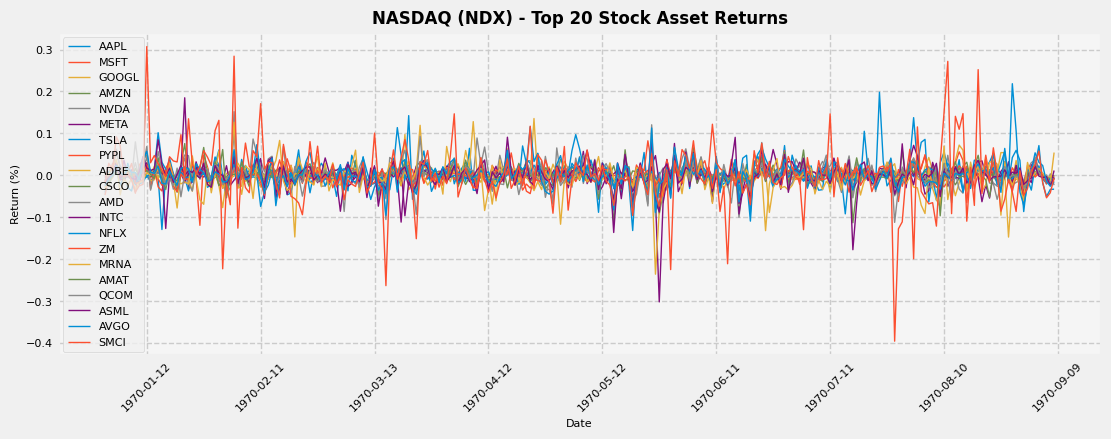

In [6]:
# Plot - Top 10 Stock Asset Returns
df_plot(df = ndx_yield_df, title = 'NASDAQ (NDX) - Top 20 Stock Asset Returns', ylabel = 'Return (%)')

In [7]:
# Random Weghts Generator
def random_weights(assets, min_asset, max_asset):
    
    # Random #1: Portfolio simulation composed by nassets (random between min_asset and max_asset)
    nasset = np.random.randint(min_asset, max_asset)

    # Random #2: Random choice of the nassets (without replacement)
    passet = np.random.choice(assets, nasset, replace = False)

    # Random #3: Random choice of the weights (sum 1)
    weights = list()
    limit = 1
    for i in range(nasset):
        # Last asset the rest of the weight
        if (i == (nasset - 1)):
            weights.append(limit)
        else:
            random_weight = np.random.uniform(0, limit)
            weights.append(random_weight)
            limit = limit - random_weight

    # Weights allocation (rest 0)
    random_weights = list()
    pos_i = 0
    for i in range(assets):
        if i in passet:
            random_weights.append(weights[pos_i])
            pos_i += 1
        else:
            random_weights.append(0)
    
    return random_weights

In [8]:
# Markowitz Efficient Frontier
def markowitz_frontier(df, nsim = 1000):  

    # Yield / Returns
    df_yield = np.log(df).diff() 
    df_yield = df_yield.iloc[1:,:]

    # Variance-Covariance Matrix
    mcov = df_yield.cov()
    mcov = mcov.to_numpy(dtype = 'float') 

    # Daily Yield
    init_price = df.iloc[0,:]
    final_price = df.iloc[-1,:]
    daily_yield = np.log(final_price / init_price) / df.shape[0]

    # Loop
    init_value = -100
    pbe_yield = 0
    pbe_risk = 0
    all_port_yield = []
    all_port_risk = []
    nblock = int(np.ceil(nsim / 1000))
    fig = plt.figure(figsize = (10, 6))
    ax = fig.gca()
    ax.set_facecolor('whitesmoke')
    for _ in range(nblock):

        # Random Weights Matrix
        mweights = np.array([random_weights(assets = ndx_df.shape[1], min_asset = 1, max_asset = 10) for _ in range(1000)])

        # Portfolio Yield / Return
        aux = daily_yield.values * mweights
        portfolio_yield = aux.sum(axis = 1) * 252

        # Portfolio Risk
        aux = np.dot(mweights, mcov)
        portfolio_risk = pow((aux * mweights).sum(axis = 1), 0.5) * np.sqrt(252)

        # Portfolio Yield / Risk Filtering
        risk_filter = portfolio_risk < np.percentile(portfolio_risk, 99)
        portfolio_risk = portfolio_risk[risk_filter]
        portfolio_yield = portfolio_yield[risk_filter]

        yield_filter = portfolio_yield > np.percentile(portfolio_yield, 1)
        portfolio_risk = portfolio_risk[yield_filter]
        portfolio_yield = portfolio_yield[yield_filter]

        # Portfolio Efficiency
        ports_00 = (portfolio_yield == 0) * (portfolio_risk == 0)
        portfolio_risk[ports_00] = 0.0000001
        portfolio_efficiency = portfolio_yield / portfolio_risk

        # Efficient Frontier
        all_port_yield.extend(portfolio_yield)
        all_port_risk.extend(portfolio_risk)

        # Best Portfolio
        best_portfolio = max(portfolio_efficiency)
        if best_portfolio > init_value:
            pos_best_portfolio = np.where(portfolio_efficiency == best_portfolio)[0]
            optimal_portfolio = mweights[pos_best_portfolio, :]    
            pos_optimal_portfolio_assets = np.where(optimal_portfolio != 0)
            weights_opt_portfolio = optimal_portfolio[pos_optimal_portfolio_assets]            
            assets_optimal_port = df_yield.columns.values[pos_optimal_portfolio_assets[1]]
            pbe_yield = portfolio_yield[pos_best_portfolio]
            pbe_risk = portfolio_risk[pos_best_portfolio]
            init_value = best_portfolio

        # Plot
        ax.scatter(x = portfolio_risk, y = portfolio_yield, c = np.arange(len(portfolio_risk)), cmap = 'YlGnBu', marker = 'o', s = 10, alpha = 0.4)

    # Efficient Frontier
    all_port_yield = np.array(all_port_yield)
    all_port_risk = np.array(all_port_risk)
    sorted_indices = np.argsort(all_port_risk)
    sorted_risk = all_port_risk[sorted_indices]
    sorted_yield = all_port_yield[sorted_indices]
    eff_front_yield = []
    eff_front_risk = []
    max_yield = float('-inf')
    for r, y in zip(sorted_risk, sorted_yield):
        if y > max_yield:
            eff_front_risk.append(r)
            eff_front_yield.append(y)
            max_yield = y

    # Plot
    ax.scatter(x = pbe_risk, y = pbe_yield, label = 'Optimal Portfolio', marker = 'X', s = 100, color = 'crimson', zorder = 10)
    ax.plot(eff_front_risk, eff_front_yield, linestyle = '-.', color = 'black', linewidth = 2, label = 'Efficient Frontier', alpha = 0.8)
    plt.grid(linestyle = '--')
    plt.title('MARKOWITZ EFFICIENT FRONTIER - NASDAQ (NDX) Top 20 Stock Asset Prices', fontsize = 12, fontweight = 'bold')
    plt.xlabel('Risk (Standard Deviation)', fontsize = 8)
    ax.tick_params(axis = 'x', labelsize = 8)
    plt.ylabel('Expected Yield', fontsize = 8)
    ax.tick_params(axis = 'y', labelsize = 8)
    legend = plt.legend(prop = {'size': 8}, frameon = True, loc = 'upper left')
    legend.get_frame().set_linewidth(0.5)
    #fig.savefig('../res/Nasdaq_MarkowitzEfficientFrontier.png', dpi = fig.dpi)
    plt.show()

    return assets_optimal_port, weights_opt_portfolio, best_portfolio

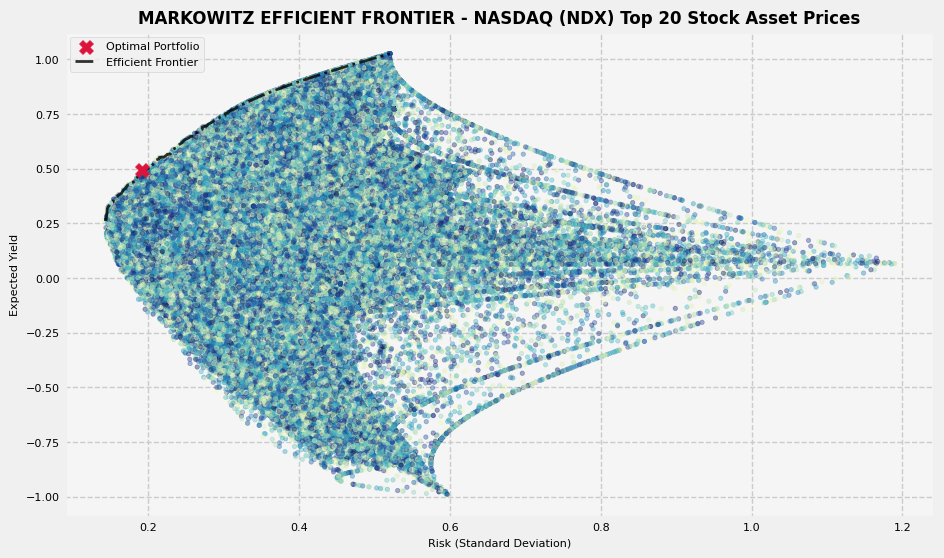

Optimal Portfolio Configuration:
['AAPL' 'AMZN' 'TSLA' 'PYPL' 'ADBE' 'AMD' 'ZM' 'QCOM' 'ASML']
[4.63690430e-01 4.96881830e-01 3.68184600e-02 1.78126695e-03
 5.12853693e-04 7.03202373e-06 2.52269299e-04 2.10084610e-05
 3.48487801e-05]


In [9]:
# Markowitz Efficient Frontier
ndx_assets_opt_portfolio, ndx_weights_opt_portfolio, best_portfolio = markowitz_frontier(ndx_df, nsim = 1000000)
print('Optimal Portfolio Configuration:')
print(ndx_assets_opt_portfolio)
print(ndx_weights_opt_portfolio)